In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

FIGURE_DIR = Path('../../book/book/images')


In [6]:
simdata = pd.read_csv('../src/bettercode/data/ricker_model/ricker_recovery_20260110_163720.csv')

In [7]:
simdata.columns

Index(['sim_id', 'true_r', 'true_sigma', 'true_phi', 'est_r_mean',
       'est_sigma_mean', 'est_phi_mean', 'est_r_median', 'est_sigma_median',
       'est_phi_median', 'est_r_std', 'est_sigma_std', 'est_phi_std',
       'error_r_mean', 'error_sigma_mean', 'error_phi_mean', 'error_r_median',
       'error_sigma_median', 'error_phi_median', 'mae', 'coverage_r',
       'coverage_sigma', 'coverage_phi', 'coverage_all', 'n_posterior_samples',
       'n_time_steps'],
      dtype='object')

In [8]:
simdata[['true_r', 'est_r_mean']].corr()

,true_r,est_r_mean
true_r,1.00000,0.84254
est_r_mean,0.84254,1.00000


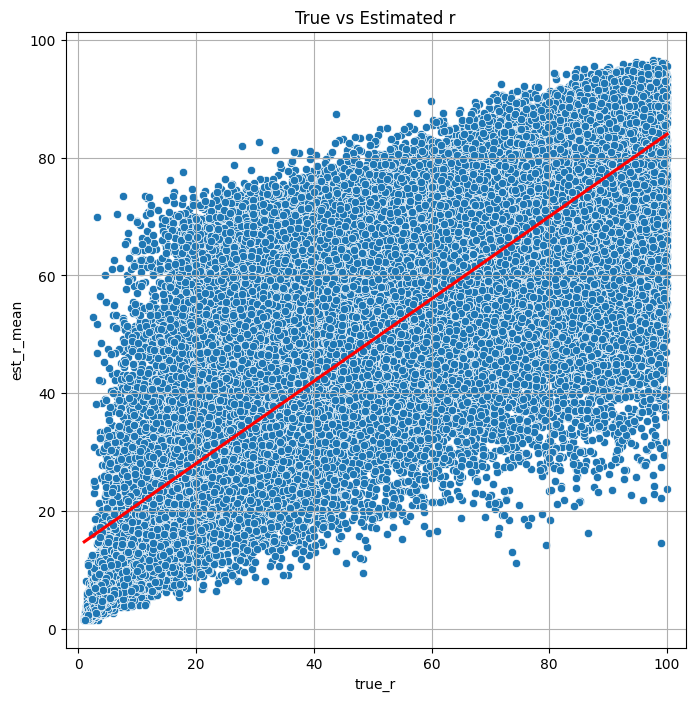

In [9]:
def plot_true_vs_estimated_r(simdata, variable='r'):
    plt.figure(figsize=(8, 8))
    sns.scatterplot(data=simdata, x=f'true_{variable}', y=f'est_{variable}_mean')
    plt.xlabel(f'True {variable}')
    plt.ylabel(f'Estimated {variable} Mean')
    plt.title(f'True vs Estimated {variable}')
    # ensure equal axes
    plt.axis('equal')

    plt.grid(True)
    # show regression line
    sns.regplot(data=simdata, x=f'true_{variable}', y=f'est_{variable}_mean', scatter=False, color='red')

plot_true_vs_estimated_r(simdata, variable='r')

In [6]:
simdata[['true_phi', 'est_phi_mean']].corr()

,true_phi,est_phi_mean
true_phi,1.000000,0.929191
est_phi_mean,0.929191,1.000000


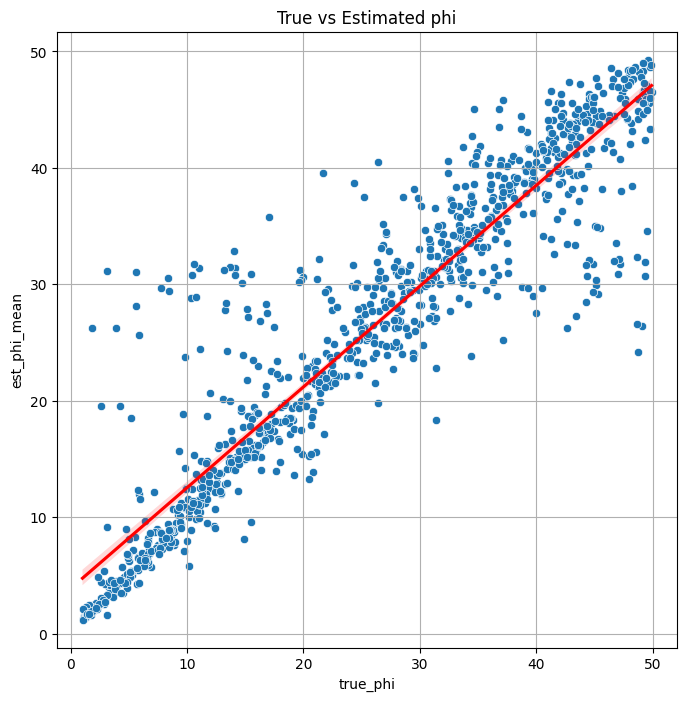

In [17]:
plot_true_vs_estimated_r(simdata, variable='phi')

In [ ]:
simdata[['true_sigma', 'est_sigma_mean']].corr()    sns.scatterplot(data=simdata, x='true_r', y='est_r_mean')
    plt.xlabel('True r')
    plt.ylabel('Estimated r Mean')
    plt.title('True vs Estimated r')
    # ensure equal axes
    plt.axis('equal')
    plt.xlim(simdata['true_r'].min(), simdata['true_r'].max())
    plt.ylim(simdata['est_r_mean'].min(), simdata['est_r_mean'].max())
    plt.grid(True)
    # show regression line
    sns.regplot(data=simdata, x='true_r', y='est_r_mean', scatter=False, color='red')

,true_sigma,est_sigma_mean
true_sigma,1.000000,0.918671
est_sigma_mean,0.918671,1.000000


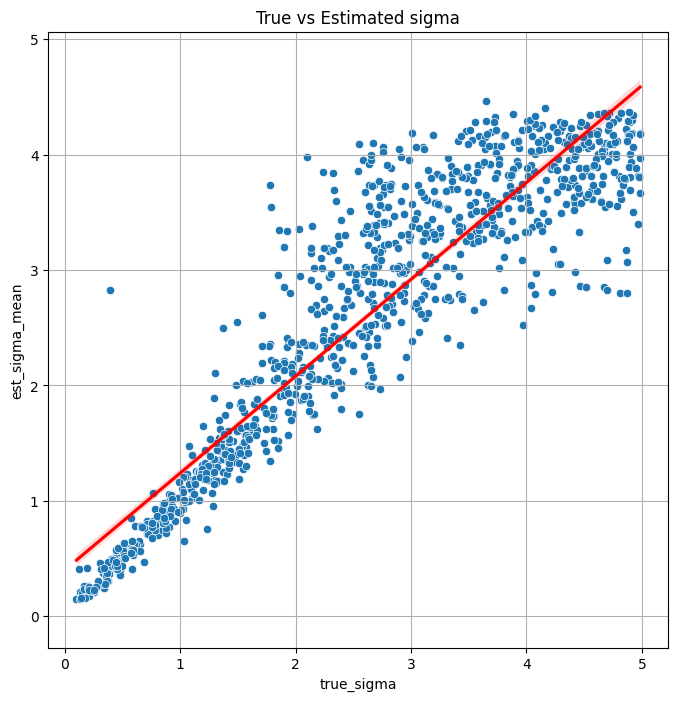

In [19]:
plot_true_vs_estimated_r(simdata, variable='sigma')

In [9]:
simdata[[i for i in simdata.columns if 'coverage_' in i]].mean()

coverage_r        0.909
coverage_sigma    0.882
coverage_phi      0.878
coverage_all      0.727
dtype: float64

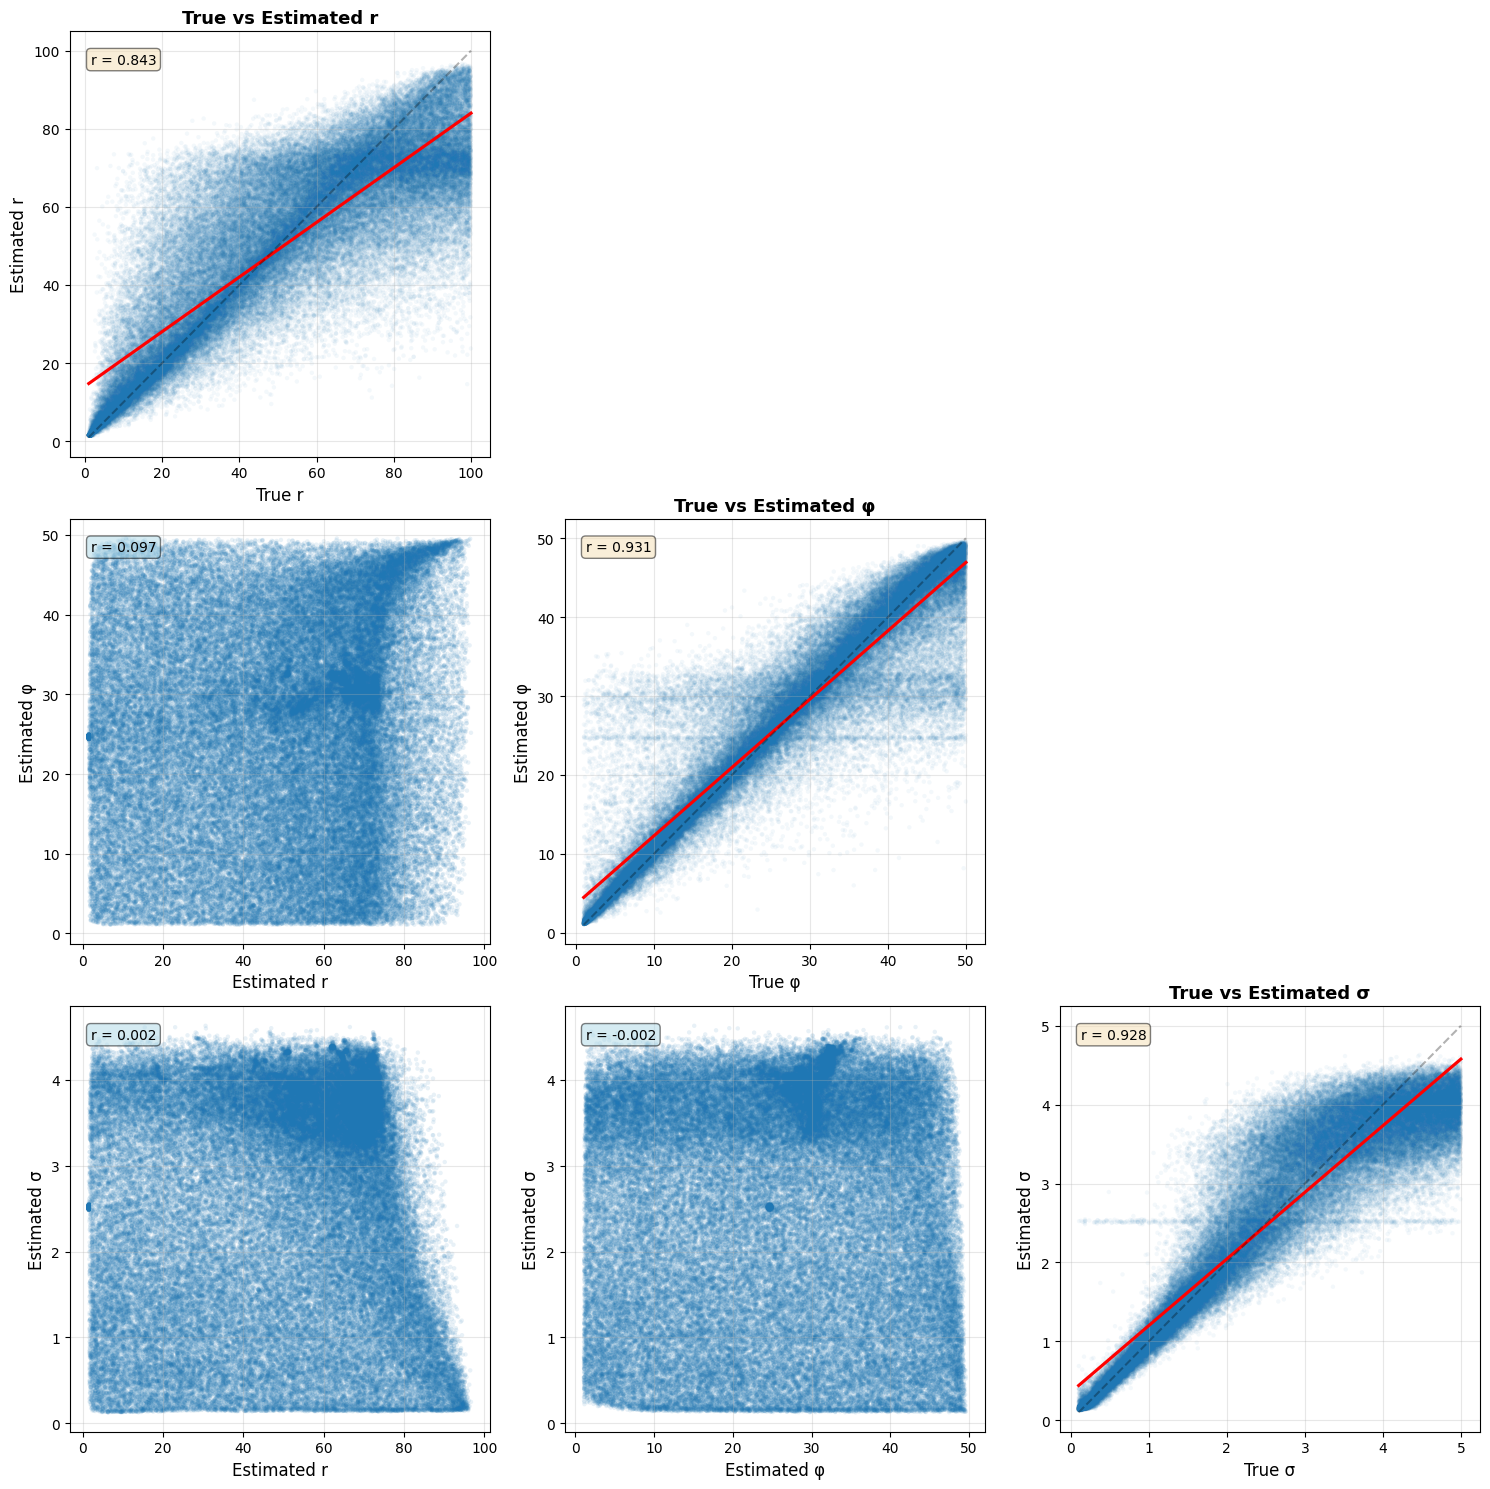

In [18]:
# Create matrix of scatterplots
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

variables = ['r', 'phi', 'sigma']
var_labels = {'r': 'r', 'phi': 'φ', 'sigma': 'σ'}

# Diagonal: True vs Estimated
for i, var in enumerate(variables):
    ax = axes[i, i]
    ax.scatter(simdata[f'true_{var}'], simdata[f'est_{var}_mean'], alpha=0.05, s=10, edgecolors='none')
    
    # Add regression line
    sns.regplot(data=simdata, x=f'true_{var}', y=f'est_{var}_mean', 
                scatter=False, color='red', ax=ax)
    
    # Add identity line
    min_val = min(simdata[f'true_{var}'].min(), simdata[f'est_{var}_mean'].min())
    max_val = max(simdata[f'true_{var}'].max(), simdata[f'est_{var}_mean'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3, label='Identity')
    
    ax.set_xlabel(f'True {var_labels[var]}', fontsize=12)
    ax.set_ylabel(f'Estimated {var_labels[var]}', fontsize=12)
    ax.set_title(f'True vs Estimated {var_labels[var]}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Calculate correlation
    corr = simdata[[f'true_{var}', f'est_{var}_mean']].corr().iloc[0, 1]
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, 
            verticalalignment='top', fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Lower off-diagonal: Estimated parameters against each other
for i in range(3):
    for j in range(3):
        if i > j:  # Lower triangle
            ax = axes[i, j]
            var_x = variables[j]
            var_y = variables[i]
            
            ax.scatter(simdata[f'est_{var_x}_mean'], simdata[f'est_{var_y}_mean'], alpha=0.1, s=10, edgecolors='none')
            ax.set_xlabel(f'Estimated {var_labels[var_x]}', fontsize=12)
            ax.set_ylabel(f'Estimated {var_labels[var_y]}', fontsize=12)
            ax.grid(True, alpha=0.3)
            
            # Calculate correlation
            corr = simdata[[f'est_{var_x}_mean', f'est_{var_y}_mean']].corr().iloc[0, 1]
            ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, 
                    verticalalignment='top', fontsize=10,
                    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
        elif i < j:  # Upper triangle - remove
            fig.delaxes(axes[i, j])

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'sbi_ricker_parameter_estimation_scatter_matrix.png', dpi=300)
plt.show()